In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Finds the folder where THIS script lives, then gets its parent (project root)
project_root = Path("eda.ipynb").resolve().parent.parent
txt_path = project_root / 'data' / 'data.csv'
df = pd.read_csv(txt_path)


1. Overview of the Data:
○ Understand the structure of the dataset, including the number of rows,
columns, and data types.


In [16]:

df.shape

(95662, 16)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [23]:
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
# Convert system IDs to strings so they are treated as categorical variables
id_cols = ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 
           'CustomerId', 'ProviderId', 'ProductId', 'CountryCode']
df[id_cols] = df[id_cols].astype(str)

2. Summary Statistics

Understand the central tendency, dispersion, and shape of the dataset’s
distribution.


In [20]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [28]:
# 1. Calculate skewness and kurtosis
skew_vals = df.skew(numeric_only=True)
kurt_vals = df.kurt(numeric_only=True)

# 2. Combine them into a clean summary table
shape_analysis = pd.DataFrame({
    'Skewness': skew_vals,
    'Kurtosis': kurt_vals
})

# 3. Display the results rounded to 2 decimal places
print("=== SHAPE ANALYSIS: SKEWNESS & KURTOSIS ===")
print(shape_analysis.round(2))

=== SHAPE ANALYSIS: SKEWNESS & KURTOSIS ===
                 Skewness  Kurtosis
Amount              51.10   3363.13
Value               51.29   3378.07
PricingStrategy      1.66      2.09
FraudResult         22.20    490.69


3. Distribution of Numerical Features

Visualize the distribution of numerical features to identify patterns, skewness,
and potential outliers.

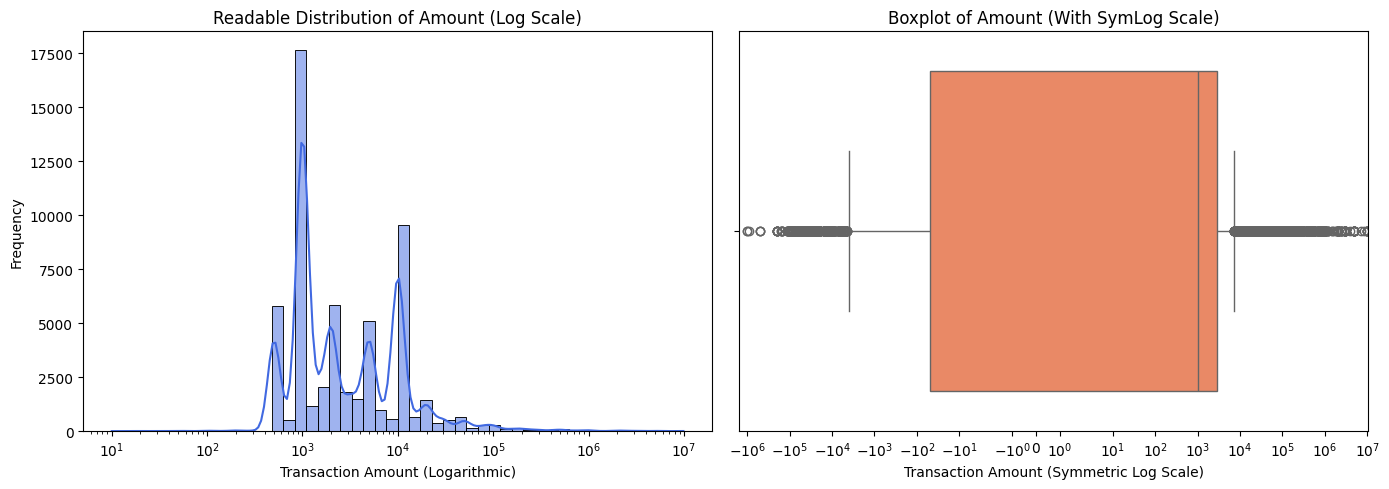

In [ ]:
# Set up the side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1HISTOGRAM: Using log_scale=True (Handles positive values cleanly)
positive_amounts = df[df['Amount'] > 0]['Amount']
sns.histplot(positive_amounts, bins=50, kde=True, ax=axes[0], color='royalblue', log_scale=True)
axes[0].set_title('Readable Distribution of Amount (Log Scale)')
axes[0].set_xlabel('Transaction Amount (Logarithmic)')
axes[0].set_ylabel('Frequency')

# 2. BOXPLOT: Using SymLog scale to  handle any negative/zero values
sns.boxplot(x=df['Amount'], ax=axes[1], color='coral')
axes[1].set_xscale('symlog')  # Symlog handles negative numbers, 0, and massive positives
axes[1].set_title('Boxplot of Amount (With SymLog Scale)')
axes[1].set_xlabel('Transaction Amount (Symmetric Log Scale)')

plt.tight_layout()
plt.show()


C:\Users\Hermela\AppData\Local\Temp\ipykernel_840\394938041.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudResult', data=df, palette='Set2')


Text(0.5, 1.0, 'Fraud vs. Legitimate Transaction Counts')

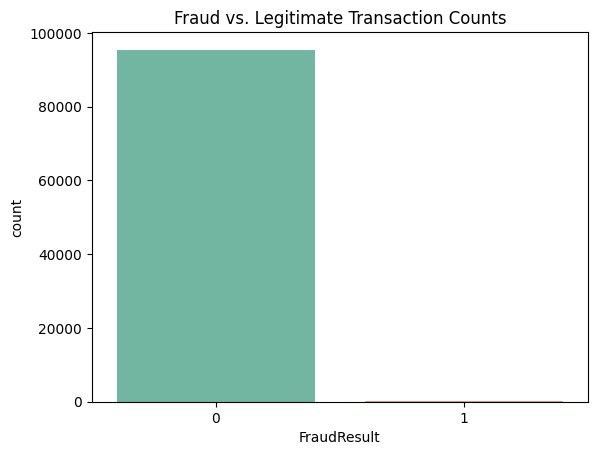

In [39]:
sns.countplot(x='FraudResult', data=df, palette='Set2')
plt.title('Fraud vs. Legitimate Transaction Counts')

Text(0.5, 1.0, 'Log-Scaled Distribution of Transaction Value')

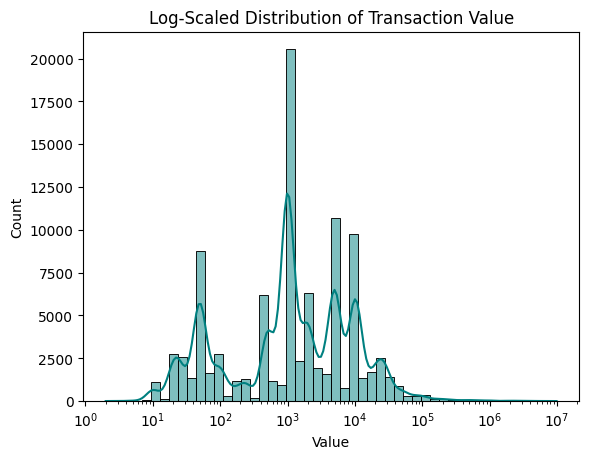

In [ ]:
sns.histplot(df['Value'], bins=50, kde=True, log_scale=True, color='teal')
plt.title('Log-Scaled Distribution of Transaction Value')



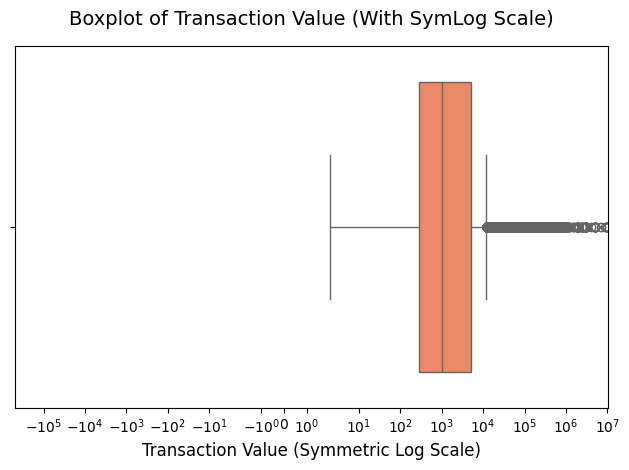

In [ ]:
sns.boxplot(x=df['Value'], color='coral')
# 3. Apply SymLog scale to handle the massive range cleanly
plt.xscale('symlog')
# 4. Set accurate titles and labels
plt.title('Boxplot of Transaction Value (With SymLog Scale)', fontsize=14, pad=15)
plt.xlabel('Transaction Value (Symmetric Log Scale)', fontsize=12)

# 5. Clean layout adjustments
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Frequency of Pricing Strategies')

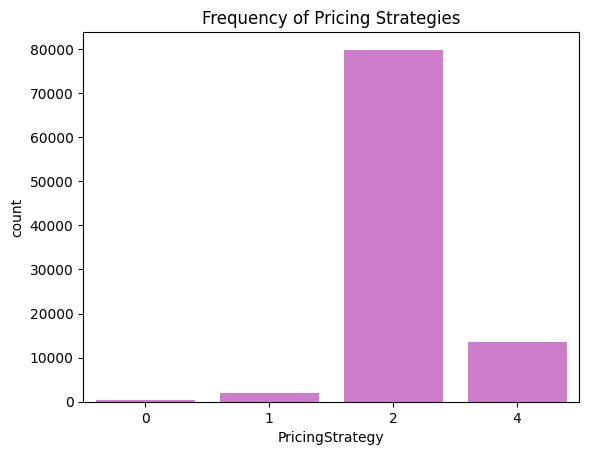

In [48]:
sns.countplot(x='PricingStrategy', data=df, color='orchid')
plt.title('Frequency of Pricing Strategies')


4. Distribution of Categorical Features

○ Analyzing the distribution of categorical features provides insights into the
frequency and variability of categories.


5. Correlation Analysis
○ Understanding the relationship between numerical features.

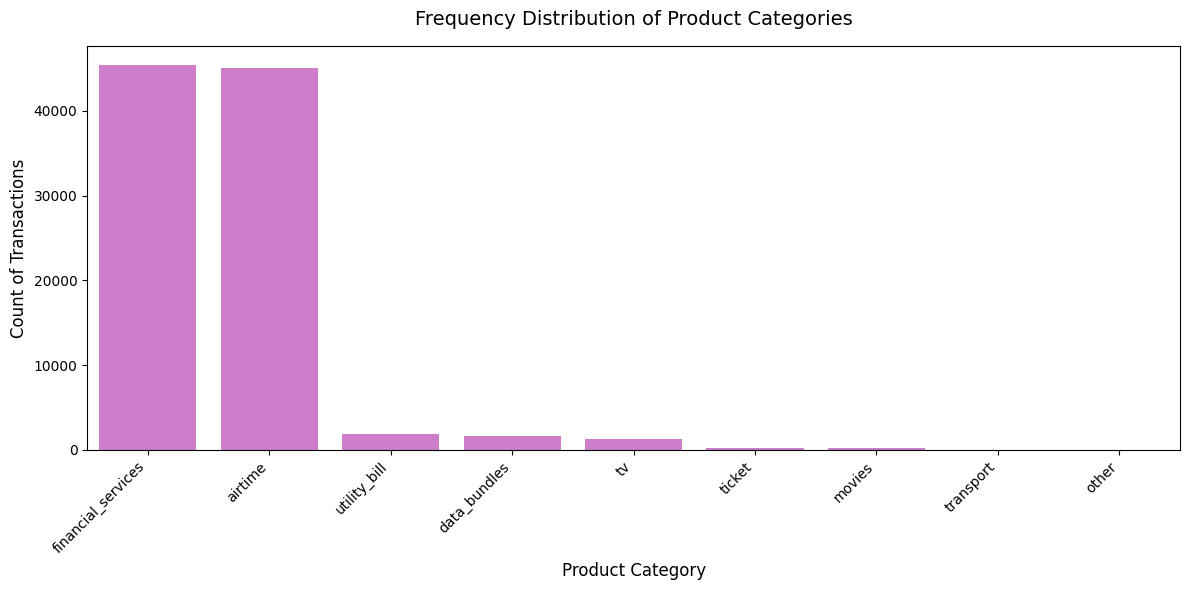

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Enlarge the figure size so categories have plenty of room
plt.figure(figsize=(12, 6))

# 2. Plot the categories sorted from highest count to lowest count
sns.countplot(
    x='ProductCategory', 
    data=df, 
    color='orchid', 
    order=df['ProductCategory'].value_counts().index
)

# 3. ROTATE THE LABELS: This stops text from overlapping
plt.xticks(rotation=45, ha='right')

# 4. Fix the title to match the column
plt.title('Frequency Distribution of Product Categories', fontsize=14, pad=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Count of Transactions', fontsize=12)

# 5. Prevent the rotated labels from getting clipped off the bottom edge
plt.tight_layout()
plt.show()


6. Identifying Missing Values
○ Identify missing values to determine missing data and decide on appropriate
imputation strategies.


In [ ]:
# Count missing values per column
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

print(missing_counts)



TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []
